In [23]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

In [33]:
data = pd.read_csv("C:/Users/mayan/Downloads/global air pollution dataset.csv")

print(data.head())
print(data.columns)
print(data.isnull().sum())
data = data.dropna()

              Country              City  AQI Value AQI Category  CO AQI Value  \
0  Russian Federation        Praskoveya         51     Moderate             1   
1              Brazil  Presidente Dutra         41         Good             1   
2               Italy   Priolo Gargallo         66     Moderate             1   
3              Poland         Przasnysz         34         Good             1   
4              France          Punaauia         22         Good             0   

  CO AQI Category  Ozone AQI Value Ozone AQI Category  NO2 AQI Value  \
0            Good               36               Good              0   
1            Good                5               Good              1   
2            Good               39               Good              2   
3            Good               34               Good              0   
4            Good               22               Good              0   

  NO2 AQI Category  PM2.5 AQI Value PM2.5 AQI Category  
0             Good     

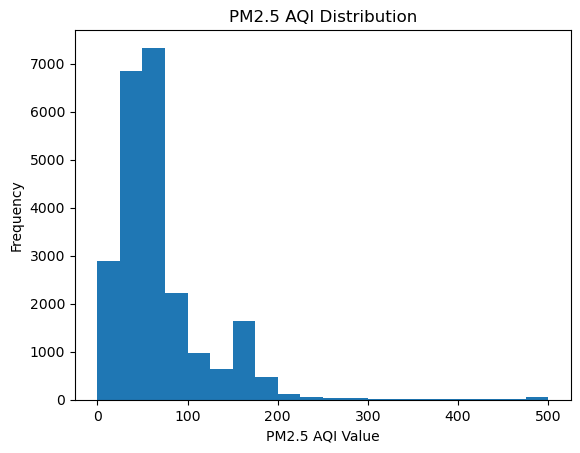

In [25]:
# 3 Graph 1 : PM2.5 Distribution
plt.hist(data['PM2.5 AQI Value'], bins=20)

plt.title("PM2.5 AQI Distribution")
plt.xlabel("PM2.5 AQI Value")
plt.ylabel("Frequency")

plt.show()


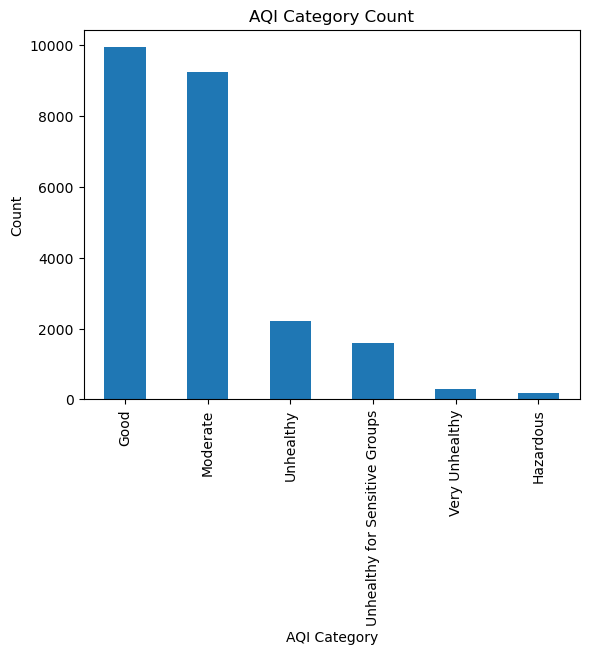

In [26]:
# 4 Graph 2 : AQI Category Count
data['AQI Category'].value_counts().plot(kind='bar')

plt.title("AQI Category Count")
plt.xlabel("AQI Category")
plt.ylabel("Count")

plt.show()

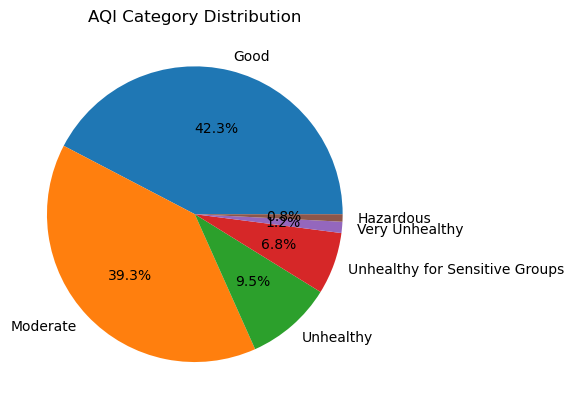

In [28]:

aqi_counts = data['AQI Category'].value_counts()

plt.pie(aqi_counts, labels=aqi_counts.index, autopct='%1.1f%%')

plt.title("AQI Category Distribution")

plt.show()

In [31]:
X = data[['CO AQI Value','Ozone AQI Value','NO2 AQI Value','PM2.5 AQI Value']]
y = data['AQI Category']


# 7 Train Test Split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42)


# 8 Train Model
model = DecisionTreeClassifier()

model.fit(X_train,y_train)


# 9 Prediction
prediction = model.predict(X_test)


# 10 Accuracy
accuracy = accuracy_score(y_test,prediction)
print("Model Accuracy:", accuracy)

Model Accuracy: 0.9997869166844237


In [35]:
sample = pd.DataFrame([[50,60,40,120]],
columns=['CO AQI Value','Ozone AQI Value','NO2 AQI Value','PM2.5 AQI Value'])

result = model.predict(sample)

print("Predicted AQI Category:", result)

Predicted AQI Category: ['Unhealthy for Sensitive Groups']
